Artificial Neural Network for MNIST Image Classification

In [1]:
#imports
import tensorflow as tf

lOAD DATASET

In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

print("x_train shape",x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape (60000, 28, 28)


In [3]:
import os

os.makedirs("images", exist_ok=True)

print("Images folder created!")

Images folder created!


Sample Digits

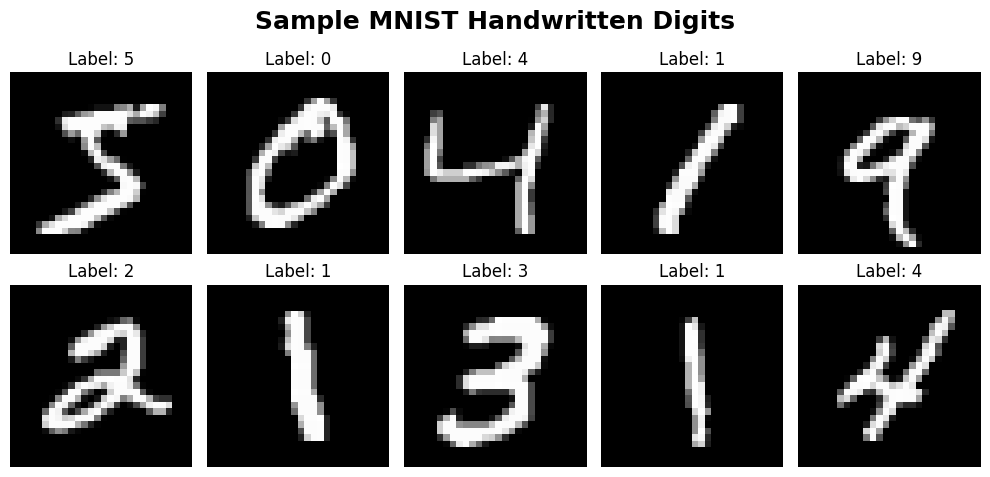

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle(
    "Sample MNIST Handwritten Digits",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "images/sample_digits.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

class distribution

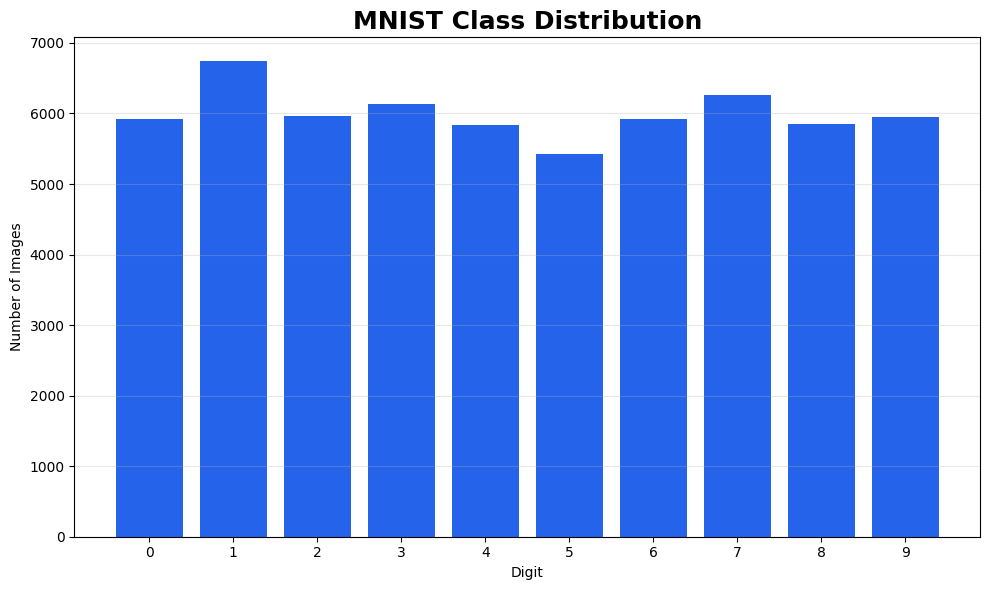

In [5]:
import matplotlib.pyplot as plt
import numpy as np

classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,6))

plt.bar(classes, counts, color="#2563EB")

plt.title(
    "MNIST Class Distribution",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Digit")

plt.ylabel("Number of Images")

plt.xticks(classes)

plt.grid(axis='y', alpha=.3)

plt.tight_layout()

plt.savefig(
    "images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

BUILD THE MODEL

In [6]:
model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


COMPILE THE MODEL

In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

TRAIN THE MODEL

In [8]:
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9139 - loss: 0.2938 - val_accuracy: 0.9597 - val_loss: 0.1373
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9579 - loss: 0.1413 - val_accuracy: 0.9695 - val_loss: 0.1005
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9682 - loss: 0.1064 - val_accuracy: 0.9729 - val_loss: 0.0890
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9721 - loss: 0.0888 - val_accuracy: 0.9752 - val_loss: 0.0779
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9763 - loss: 0.0745 - val_accuracy: 0.9770 - val_loss: 0.0733
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9797 - loss: 0.0647 - val_accuracy: 0.9786 - val_loss: 0.0705
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9815 - loss: 0.0575 - val_accuracy: 0.9785 - val_loss: 0.0688
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9821 - loss: 0.0526 - 

Training Loss Curve

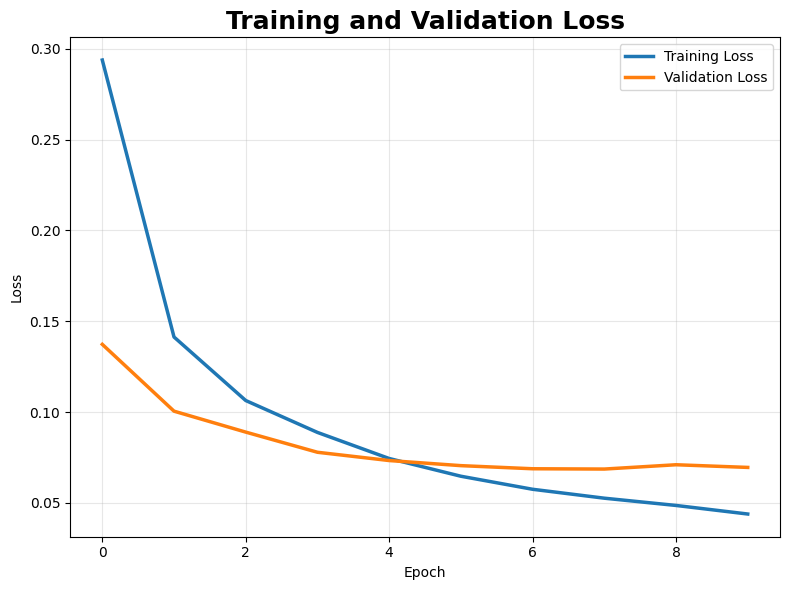

In [10]:
plt.figure(figsize=(8,6))

plt.plot(
    r.history['loss'],
    linewidth=2.5,
    label='Training Loss'
)

plt.plot(
    r.history['val_loss'],
    linewidth=2.5,
    label='Validation Loss'
)

plt.title(
    "Training and Validation Loss",
    fontsize=18,
    weight='bold'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "images/training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Training Accuracy Curve

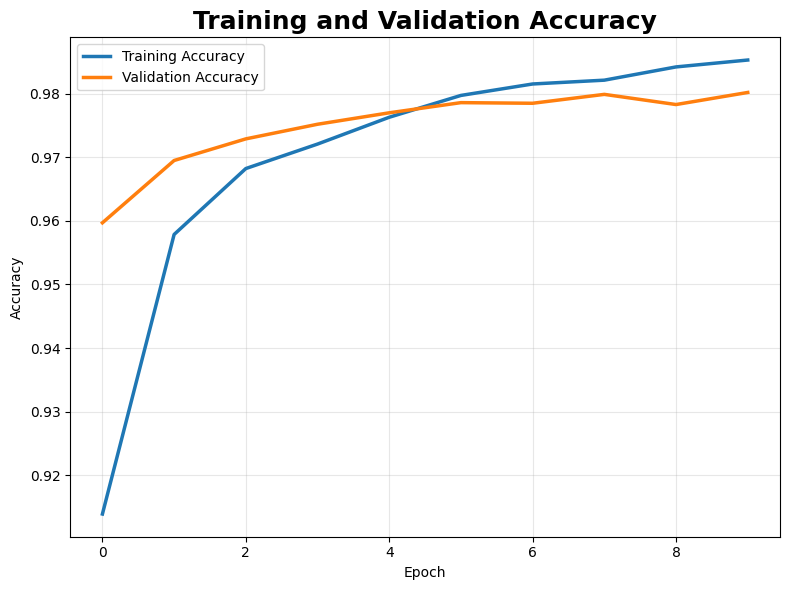

In [11]:
plt.figure(figsize=(8,6))

plt.plot(
    r.history['accuracy'],
    linewidth=2.5,
    label='Training Accuracy'
)

plt.plot(
    r.history['val_accuracy'],
    linewidth=2.5,
    label='Validation Accuracy'
)

plt.title(
    "Training and Validation Accuracy",
    fontsize=18,
    weight='bold'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "images/training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

EVALUATE THE MODEL

In [12]:
print(model.evaluate(x_test, y_test) )

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9802 - loss: 0.0695
[0.06954740732908249, 0.9801999926567078]


Confusion Matrix

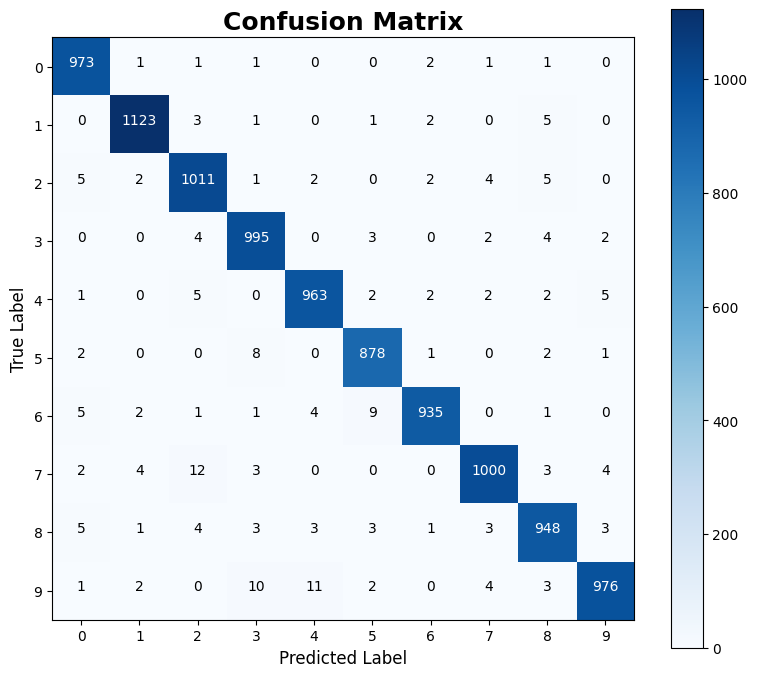

In [13]:
from sklearn.metrics import confusion_matrix
import itertools

# Predict test labels
p_test = model.predict(x_test, verbose=0).argmax(axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, p_test)

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8,7))

    plt.imshow(cm, interpolation='nearest', cmap=cmap)

    plt.title(title, fontsize=18, weight='bold')

    plt.colorbar()

    tick_marks = np.arange(len(classes))

    plt.xticks(tick_marks, classes)

    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'

    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]),
                                  range(cm.shape[1])):

        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            ha="center",
            color="white" if cm[i, j] > thresh else "black"
        )

    plt.ylabel("True Label", fontsize=12)

    plt.xlabel("Predicted Label", fontsize=12)

    plt.tight_layout()

    plt.savefig(
        "images/confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

plot_confusion_matrix(cm, classes=list(range(10)))

Misclassified Digits

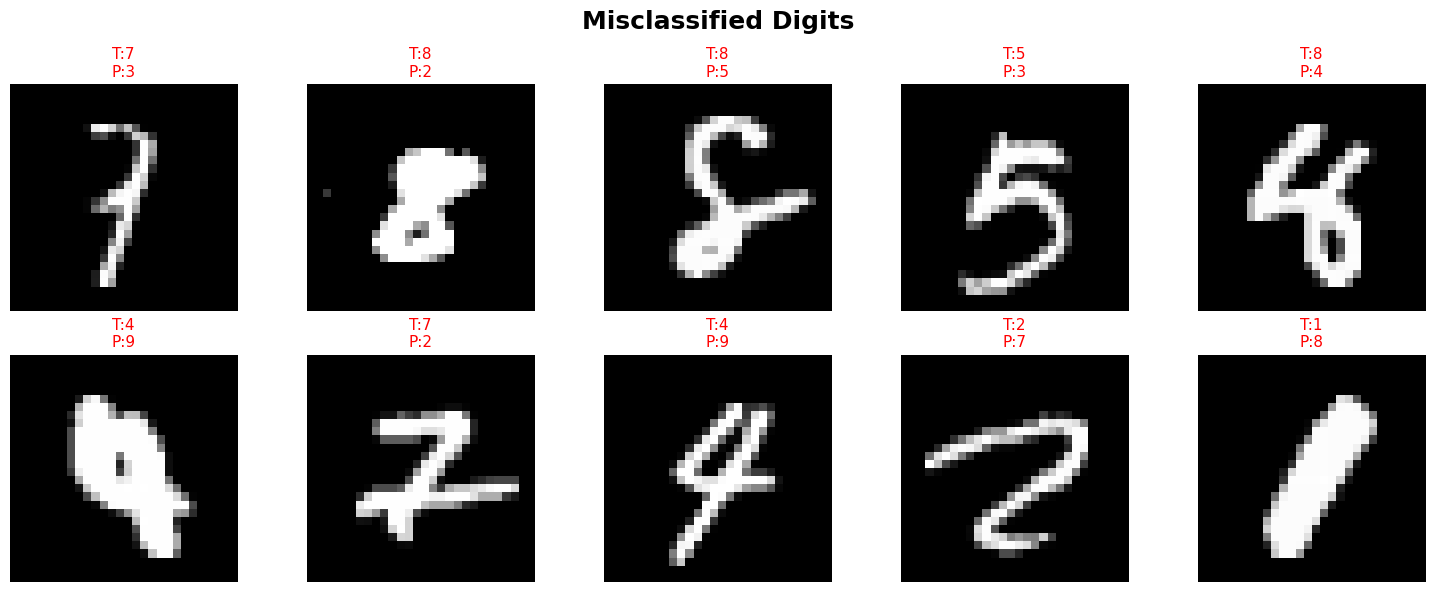

In [14]:
misclassified_idx = np.where(p_test != y_test)[0]

plt.figure(figsize=(15,6))

sample = np.random.choice(misclassified_idx, 10)

for i, idx in enumerate(sample):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[idx], cmap="gray")

    plt.axis("off")

    plt.title(
        f"T:{y_test[idx]}\nP:{p_test[idx]}",
        color="red",
        fontsize=11
    )

plt.suptitle(
    "Misclassified Digits",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "images/misclassified_digits.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ANN FOR REGRESSION


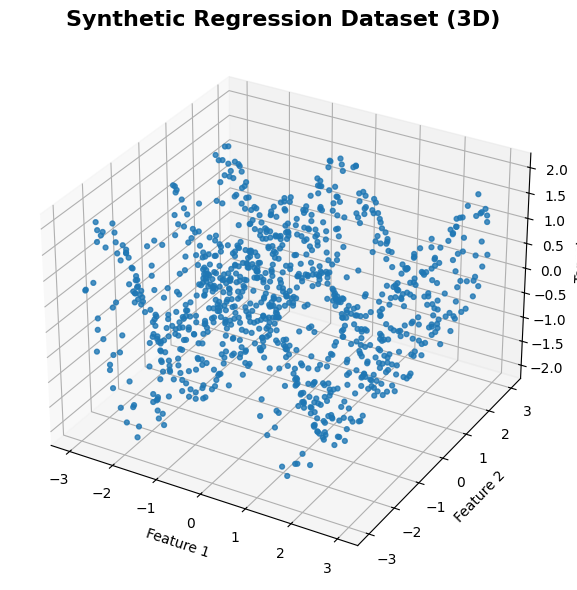

In [17]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic dataset
N = 1000

X = np.random.random((N, 2)) * 6 - 3

Y = np.cos(2 * X[:, 0]) + np.cos(3 * X[:, 1])

# Create figure
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X[:, 0],
    X[:, 1],
    Y,
    s=12,
    alpha=0.8
)

ax.set_title(
    "Synthetic Regression Dataset (3D)",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Feature 1")

ax.set_ylabel("Feature 2")

ax.set_zlabel("Target")

plt.tight_layout()

plt.savefig(
    "images/regression_dataset_3d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
#Build the model
model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(128,input_shape =(2,1),activation='relu'),
        tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
#compile and fit
opt = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=opt, loss='mse')
r = model.fit(X, Y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9339   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9058 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8954 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9283
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9048 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9002 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8991
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9007 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8996 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9014 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8995 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9014 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8994 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8985 
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - los

Training Loss for ANN Regression

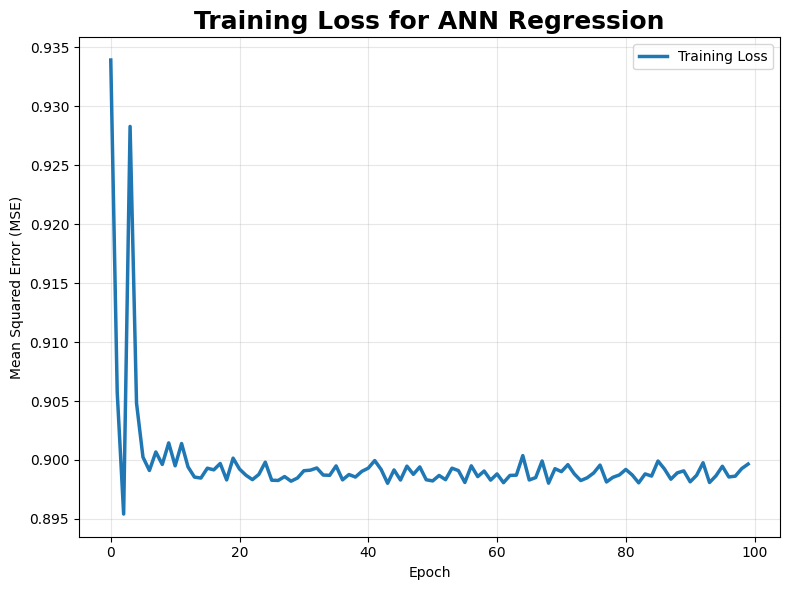

In [20]:
plt.figure(figsize=(8,6))

plt.plot(
    r.history['loss'],
    linewidth=2.5,
    label='Training Loss'
)

plt.title(
    "Training Loss for ANN Regression",
    fontsize=18,
    weight='bold'
)

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error (MSE)")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "images/ann_regression_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

syntetic regression Dataset

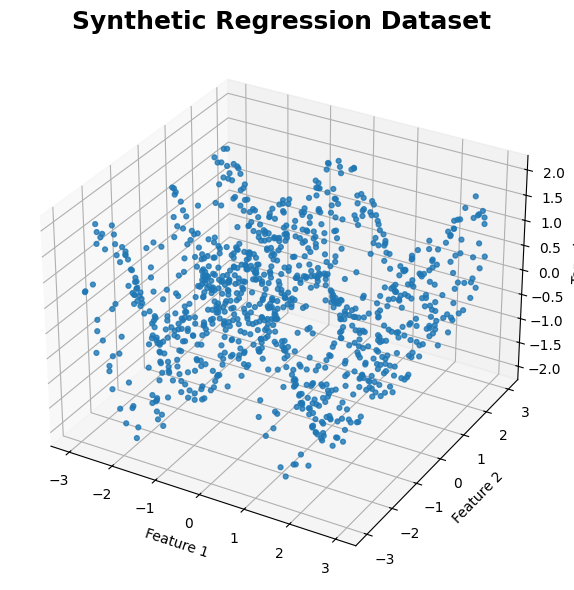

In [21]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X[:,0],
    X[:,1],
    Y,
    s=12,
    alpha=0.8
)

ax.set_title(
    "Synthetic Regression Dataset",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Target")

plt.tight_layout()

plt.savefig(
    "images/regression_dataset.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Neural Network Regression Surface

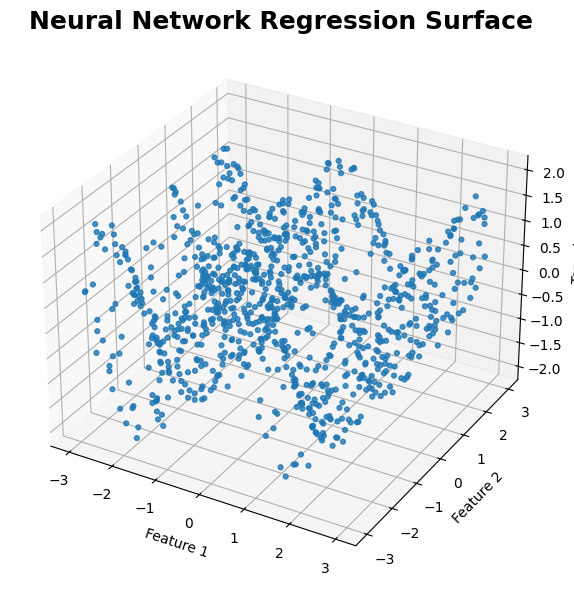

In [22]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X[:,0],
    X[:,1],
    Y,
    s=12,
    alpha=0.8
)

ax.set_title(
    "Neural Network Regression Surface",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Target")

plt.tight_layout()

plt.savefig(
    "images/regression_prediction_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
import shutil
from google.colab import files

# Create a ZIP archive
shutil.make_archive("mnist_images", "zip", "images")

# Download it
files.download("mnist_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>